In [1]:
%load_ext autoreload
%autoreload 2

import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from env.charging_env import ChargingStationEnv
from metrics.validate import report_queueing_laws, validate_episode

from policy.power.proportional import ProportionalPower
from policy.power.static import StaticPower
from policy.queue.fifo import FIFOQueuePolicy
from policy.queue.lowest_soc_diff import LowestSoCDiffQueuePolicy
from visualization.ev_curves import plot_ev_theory_vs_sim
from visualization.pile_power import plot_pile_connector_power
from config import MAX_TIME

from __future__ import annotations

from offline_cl_opt import (
    StationSpec,
    build_cl_model,
    solve_cl_model,
    vehicles_from_evs,
)
from offline_cl_opt.solution import extract_solution


In [ ]:
# Shared station / traffic inputs (simulation and offline use the same layout).
SCENARIO = {
    "n_piles": 1,
    "n_connectors": 2,
    "n_modules": 6,
    "p_module": 25.0,
    "queue_capacity": 1000,
    "mean_interarrival": 30.0,
    # None: continuous Poisson times. 1: nearest minute; 2/3/5: nearest multiple.
    "delta_arr": None,
}

# Simulation controls
SEED = 41
POLICY_SEED = 1
QUEUE_POLICY = FIFOQueuePolicy()
POWER_POLICY = ProportionalPower()

# Warm-up period: None -> config.WARMUP_PERIOD (0.0 out of the box, no
# warm-up, fully backward compatible). See sim_benchmark.ipynb for the full
# usage example / explanation of both options.
WARMUP_PERIOD = None
FLUSH_QUEUE_AT_WARMUP = False

env = ChargingStationEnv(
    **SCENARIO,
    power_policy=POWER_POLICY,
    max_time = 60 * 8,
    warmup_period=WARMUP_PERIOD,
    flush_queue_at_warmup=FLUSH_QUEUE_AT_WARMUP,
)

obs, info = env.reset(seed=SEED)
done = False
rng = np.random.default_rng(POLICY_SEED)
policy = QUEUE_POLICY
total_reward = 0.0

t0 = time.perf_counter()
while not done:
    mask = env.action_masks()
    ev, pile_id = policy.decide(obs, mask, rng, env.engine.station)
    obs, reward, done, _, info = env.step(pile_id, ev=ev)
    total_reward += reward
sim_runtime = time.perf_counter() - t0

m = env.engine.metrics
finished = m.finished_evs
arrived = m.arrived_evs
dropped = m.dropped_evs
sim_total_sojourn = float(sum(ev.departure_time - ev.arrival_time for ev in finished))
sim_mean_sojourn = m.mean_sojourn()

print(f"Finished EVs: {len(finished)}")
print(f"Arrived EVs:  {len(arrived)}")
print(f"Dropped EVs:  {len(dropped)}")
print(f"Total reward: {total_reward:.3f}")
print(f"Sim time (episode clock, TOTAL incl. warm-up): {env.engine.current_time:.1f} min "
      f"(warm-up={env.engine.warmup_period:.1f} + measured={env.engine.measurement_horizon:.1f})")
print(f"Sim wall-clock runtime:   {sim_runtime:.3f} s")

# Whole run vs. measured-phase-only (see MetricsTracker's own module
# docstring, "Warm-up period" -- identical numbers on both sides whenever
# WARMUP_PERIOD is 0, as it is by default here).
print(f"Avg L   whole-run={m.average_L():.3f}   measured-only={m.average_L(m.warmup_period):.3f}")
print(f"Avg Q   whole-run={m.average_Q():.3f}   measured-only={m.average_Q(m.warmup_period):.3f}")
print(f"Sim total sojourn  whole-run={sim_total_sojourn:.2f} min   "
      f"measured-only={m.finished_time_arrays(m.warmup_period)[2].sum():.2f} min")
print(f"Sim mean sojourn   whole-run={sim_mean_sojourn:.2f} min   "
      f"measured-only={m.mean_sojourn(m.warmup_period):.2f} min")

from metrics.validate import report_queueing_laws, validate_episode

print("\n--- Whole run ---")
reo_q_full = report_queueing_laws(env, verbose=True, post_warmup_only=False)
print("\n--- Measured phase only (post-warm-up) ---")
reo_q_post = report_queueing_laws(env, verbose=True, post_warmup_only=True)


In [ ]:
import numpy as np
from simulation.arrivals import generate_arrivals
from env.charging_env import ChargingStationEnv
from config import MAX_TIME

# Warm-up period: None -> config.WARMUP_PERIOD (0.0 out of the box, no
# warm-up, fully backward compatible). See sim_benchmark.ipynb for the full
# usage example / explanation of both options.
WARMUP_PERIOD = None
FLUSH_QUEUE_AT_WARMUP = False

# 1. Generate the EV list yourself (same object format the simulation uses internally)
rng_ = np.random.default_rng(SEED)
evs = generate_arrivals(mean_interarrival=75.0, max_time=MAX_TIME, rng=rng_, delta_arr=None)

# 2. Feed it to the simulation: mean_interarrival=None so the external list is used
env = ChargingStationEnv(
    n_piles=1, n_connectors=2, n_modules=6, p_module=25.0,
    queue_capacity=1000,
    mean_interarrival=None,   # None -> use `arrivals`, not internal sampling
    arrivals=evs,
    delta_arr=None,  # None: keep times as generated; 1 snaps to nearest minute
    warmup_period=WARMUP_PERIOD,
    flush_queue_at_warmup=FLUSH_QUEUE_AT_WARMUP,
)
obs, info = env.reset(seed=SEED)

done = False
rng = np.random.default_rng(POLICY_SEED)
policy = QUEUE_POLICY
total_reward = 0.0

t0 = time.perf_counter()
while not done:
    mask = env.action_masks()
    ev, pile_id = policy.decide(obs, mask, rng, env.engine.station)
    obs, reward, done, _, info = env.step(pile_id, ev=ev)
    total_reward += reward
sim_runtime = time.perf_counter() - t0

m = env.engine.metrics
finished = m.finished_evs
arrived = m.arrived_evs
dropped = m.dropped_evs
sim_total_sojourn = float(sum(ev.departure_time - ev.arrival_time for ev in finished))
sim_mean_sojourn = m.mean_sojourn()

print(f"Finished EVs: {len(finished)}")
print(f"Arrived EVs:  {len(arrived)}")
print(f"Dropped EVs:  {len(dropped)}")
print(f"Total reward: {total_reward:.3f}")
print(f"Sim time (episode clock, TOTAL incl. warm-up): {env.engine.current_time:.1f} min "
      f"(warm-up={env.engine.warmup_period:.1f} + measured={env.engine.measurement_horizon:.1f})")
print(f"Sim wall-clock runtime:   {sim_runtime:.3f} s")

# Whole run vs. measured-phase-only (see MetricsTracker's own module
# docstring, "Warm-up period" -- identical numbers on both sides whenever
# WARMUP_PERIOD is 0, as it is by default here).
print(f"Avg L   whole-run={m.average_L():.3f}   measured-only={m.average_L(m.warmup_period):.3f}")
print(f"Avg Q   whole-run={m.average_Q():.3f}   measured-only={m.average_Q(m.warmup_period):.3f}")
print(f"Sim total sojourn  whole-run={sim_total_sojourn:.2f} min   "
      f"measured-only={m.finished_time_arrays(m.warmup_period)[2].sum():.2f} min")
print(f"Sim mean sojourn   whole-run={sim_mean_sojourn:.2f} min   "
      f"measured-only={m.mean_sojourn(m.warmup_period):.2f} min")


In [ ]:
# Offline IP + continuous relaxations on the same station layout and the same
# arrival stream the episode already realized (no synthetic arrivals after
# simulation end). VehicleData uses each EV's arrival, battery, s_i, s_f.
cl_station = StationSpec(
    n_piles=SCENARIO["n_piles"],
    n_connectors=SCENARIO["n_connectors"],
    n_modules=SCENARIO["n_modules"],
    p_module=SCENARIO["p_module"],
)

# Offline MILP / RP controls (same arrivals + station as the finished episode)
DELTA = 1.0
MIP_GAP = 1e-3
TIME_LIMIT = 600.0  # seconds per solve; raise if the gap does not close
# Manual completion horizon for the offline models (minutes) -- models just
# the MEASURED phase, not warm-up. Must be long enough that every arrived
# EV can finish.
OFFLINE_HORIZON = MAX_TIME

sim_end = float(env.engine.current_time)
# Arrivals during the measured phase only (arrived_post_warmup, not the
# whole run's `arrived`) -- a no-op filter when WARMUP_PERIOD=0, as it is
# by default here, but correct if you set it above. arrival_time is shifted
# back by warmup_period so k_j = ceil(a_j/delta) lands inside
# [0, OFFLINE_HORIZON) -- see sim_benchmark.ipynb for the full explanation
# of why this shift is needed once warm-up is in play.
import dataclasses
offline_evs = env.engine.metrics.arrived_post_warmup
vehicles = [
    dataclasses.replace(v, a=v.a - env.engine.warmup_period)
    for v in vehicles_from_evs(offline_evs)
]


print(
    f"Offline instance: J={len(vehicles)} vehicles "
    f"(arrived during the measured phase, warmup_period={env.engine.warmup_period:.1f} min, "
    f"sim_end={sim_end:.1f} min), "
    f"horizon T={OFFLINE_HORIZON:.1f} min, delta={DELTA:g} min, "
)

In [6]:
import math
from offline_cl_dw.preprocess import columns_from_evs

# Same horizon-slot count solve_by_decomposition computes internally
# (offline_cl_dw.colgen._horizon_slots) -- columns_from_evs needs it directly.
K = math.ceil(round(OFFLINE_HORIZON / DELTA, 9))

# Turn the episode you already simulated into master columns: one real
# per-vehicle plan (pile, start, departure, power trace) per finished EV,
# read straight off its charge trace -- Section 7.2's "simulate FCFS...
# convert each vehicle's realised schedule into a plan" seed source.
vehicles_by_id = {v.id: v for v in vehicles}
extra_seed_columns = columns_from_evs(finished, vehicles_by_id, DELTA, K)


In [ ]:
from offline_cl_dw import solve_by_decomposition

dw_solution, dw_colgen = solve_by_decomposition(
    vehicles, cl_station, delta=DELTA, horizon_minutes=OFFLINE_HORIZON,
    progress=True,
)

print(f"\nbracket: [{dw_solution.LB:.3f}, {dw_solution.UB:.3f}]  "
      f"gap={dw_solution.gap:.3f}  converged={dw_solution.converged}  "
      f"iterations={dw_solution.iterations}")
# rmp_gap is the colgen stopping-criterion gap (z_RMP - LB) -- a diagnostic
# of how close column generation got to proving z_RMP == z_MP, NOT itself a
# certified bound the way `gap` (UB - LB) is.
print(f"rmp_gap (z_RMP - LB, not certified): {dw_solution.rmp_gap:.3f}")
#print(f"compact-model exact objective (from 'Build and solve' above) = {solution.objective:.3f}")
print(f"whole_module_feasible: {dw_solution.whole_module_feasible}")
#dw_solution.per_vehicle
print(
    f"Total sojourn bracket: "
    f"[{dw_solution.total_sojourn_LB:.2f}, "
    f"{dw_solution.per_vehicle['sojourn_min'].sum():.2f}]"
)

In [8]:
# --- Speedup option 1: coarse-delta seed for column generation -------------
# Solve the same instance at a much coarser slot length first: K shrinks by
# the same ratio, so both the master's 2MK rows and every pricer MILP's
# K-k_j binaries shrink with it -- a coarse solve is cheap. Refining that
# solution back onto the fine grid is *exact*, not an approximation (see
# offline_cl_dw.warm_start's own module docstring for the argument: energy,
# taper, and per-slot capacity feasibility all transfer unchanged under the
# "staircase" refinement) -- so the refined plans are genuine extra seed
# columns, on top of (or instead of) the FCFS-simulation seed used above.
import time

from offline_cl_dw import refine_solution
from offline_cl_dw.master import solve_integer
from offline_cl_dw.postprocess import whole_module_failures
from offline_cl_dw import solve_by_decomposition

DELTA_COARSE = 5.0  # must be an integer multiple of DELTA (checked by refine_solution)

t0 = time.perf_counter()
coarse_solution, coarse_colgen = solve_by_decomposition(
    vehicles, cl_station, delta=DELTA_COARSE, horizon_minutes=OFFLINE_HORIZON, progress=True,
)

[colgen] iter 1: z_RMP=647.462, best_LB=510.462, gap=137.000, exact=True, candidates=4, columns_added=4, total_columns=16
[colgen] iter 2: z_RMP=642.463, best_LB=510.462, gap=132.002, exact=False, candidates=4, columns_added=4, total_columns=20
[colgen] iter 3: z_RMP=642.207, best_LB=510.462, gap=131.745, exact=False, candidates=4, columns_added=4, total_columns=24
[colgen] iter 4: z_RMP=625.706, best_LB=510.462, gap=115.244, exact=False, candidates=4, columns_added=4, total_columns=28
[colgen] iter 5: z_RMP=620.551, best_LB=510.462, gap=110.089, exact=False, candidates=4, columns_added=4, total_columns=32
[colgen] iter 6: z_RMP=620.551, best_LB=510.462, gap=110.089, exact=False, candidates=2, columns_added=2, total_columns=34
[colgen] iter 7: z_RMP=620.551, best_LB=510.462, gap=110.089, exact=False, candidates=1, columns_added=1, total_columns=35
[colgen] iter 8: z_RMP=620.551, best_LB=510.462, gap=110.089, exact=False, candidates=1, columns_added=1, total_columns=36
[colgen] iter 9: 

In [ ]:
coarse_chosen = solve_integer(coarse_colgen.master).chosen
t_coarse = time.perf_counter() - t0
print(f"coarse solve (delta={DELTA_COARSE:g} min): {t_coarse:.2f}s, "
      f"bracket=[{coarse_solution.LB:.1f}, {coarse_solution.UB:.1f}], "
      f"converged={coarse_solution.converged}")
import math
K = math.ceil(round(OFFLINE_HORIZON / DELTA, 9))
# Refine onto the fine grid (DELTA, K -- already computed above) and check
# whole-module feasibility (Proposition 2's caveat: the DW master only
# enforces the *continuous*-module relaxation, so this is worth a look even
# though it doesn't block using the seed either way).
coarse_seed = refine_solution(coarse_chosen, DELTA_COARSE, DELTA, K)
print(f"whole-module failures in the refined seed: {whole_module_failures(coarse_seed, cl_station)}")
extra_seed_from_coarse = {j: [p] for j, p in coarse_seed.items() if not p.is_null}

In [ ]:

t0 = time.perf_counter()
dw_solution_ws, dw_colgen_ws = solve_by_decomposition(
    vehicles, cl_station, delta=DELTA, horizon_minutes=OFFLINE_HORIZON,
    extra_seed_columns=extra_seed_from_coarse, progress=True,
)
t_fine_ws = time.perf_counter() - t0
print(f"fine solve (delta={DELTA:g} min), coarse-seeded: {t_fine_ws:.2f}s, "
      f"iterations={dw_solution_ws.iterations}, converged={dw_solution_ws.converged}, "
      f"bracket=[{dw_solution_ws.LB:.3f}, {dw_solution_ws.UB:.3f}]")
print(f"  (compare against the FCFS-seeded run above: "
      f"iterations={dw_solution.iterations}, converged={dw_solution.converged})")


In [ ]:
print(
    f"Total sojourn bracket: "
    f"[{coarse_solution.total_sojourn_LB:.2f}, "
    f"{coarse_solution.per_vehicle['sojourn_min'].sum():.2f}]"
)

In [ ]:
print(
    f"Total sojourn bracket: "
    f"[{dw_solution.total_sojourn_LB:.2f}, "
    f"{dw_solution.per_vehicle['sojourn_min'].sum():.2f}]"
)

In [19]:
from offline_cl_opt import incumbent_objective

# Reuse the FIFO simulation from the sanity-check section above as the incumbent.
# Used below as an objective cutoff and a MIP-start source, not to narrow
# which variables get built (Section 9.2 argues against per-vehicle
# windowing in a congested regime like this one -- worth confirming: the
# slack it would offer, UB - sum(E_j), rarely comes in under the horizon
# here, so it wouldn't have narrowed anything anyway).
sim_departures = {ev.id: ev.departure_time for ev in env.engine.metrics.finished_evs}
UB = incumbent_objective(vehicles, cl_station, delta=1.0, horizon_minutes=OFFLINE_HORIZON,
                         incumbent_departures=sim_departures)
UB

3087.0

In [ ]:

cl_model = build_cl_model(vehicles, cl_station, break_symmetry=True, bound_departures=True,
delta=1.0, horizon_minutes=OFFLINE_HORIZON, tie_break=False)
solve_cl_model(cl_model, mip_gap=1e-4, time_limit=None, verbose=True, cutoff=UB)
solution = extract_solution(cl_model)

print(f"status={solution.status}, gap={solution.mip_gap:.2%}, runtime={solution.runtime:.2f}s")
print(f"objective (total sojourn) = {solution.objective:.3f} min, mean sojourn = {solution.mean_sojourn:.3f} min")
solution.per_vehicle

In [21]:
solution.total_sojourn

220.73784346953153

In [ ]:
# --- Speedup option 2: coarse-delta MIP start for the exact IP -------------
# Reuse coarse_seed (the coarse-delta DW solution, refined onto the fine
# grid) computed in the DW section above as a Gurobi MIP start for the exact
# compact IP -- offline_cl_dw.apply_mip_start sets .Start on every variable
# it can (u, p, eta, x, y, r, b); Gurobi validates/repairs anything it can't
# use as given (most likely r, the whole-module routing -- see
# offline_cl_dw.warm_start's own docstring).
#
# break_symmetry=False here on purpose: (25)-(26)'s forced pile/connector
# ordering (lowest vehicle id first) has no reason to agree with
# apply_mip_start's connector labels (assigned by start time via
# postprocess.assign_connectors), so combining the two would likely make
# Gurobi discard the start outright -- build_cl_model's own docstring
# already warns aggressive symmetry breaking "can interfere with warm
# starts" for the same reason.
from offline_cl_dw import apply_mip_start

cl_model_ws = build_cl_model(vehicles, cl_station, break_symmetry=False, bound_departures=True,
                              delta=DELTA, horizon_minutes=OFFLINE_HORIZON, tie_break=False)
apply_mip_start(cl_model_ws, coarse_seed, cl_station)
solve_cl_model(cl_model_ws, mip_gap=1e-4, time_limit=None, verbose=True, cutoff=UB)
solution_ws = extract_solution(cl_model_ws)

print(f"status={solution_ws.status}, gap={solution_ws.mip_gap:.2%}, runtime={solution_ws.runtime:.2f}s")
print(f"warm-started objective (sum D_j) = {solution_ws.objective:.3f} slots, "
      f"mean sojourn = {solution_ws.mean_sojourn:.3f} min")
print(f"  (compare against the cold solve above: "
      f"runtime={solution.runtime:.2f}s, objective={solution.objective:.3f})")


In [ ]:
from offline_cl_opt import solve_cl_model_adaptive

result = solve_cl_model_adaptive(vehicles, cl_station, delta=1.0, break_symmetry=True,
                        progress=True, verbose=False,
                        bound_departures=True, cutoff=UB,
                        horizon_minutes=OFFLINE_HORIZON, mip_gap=1e-4,
                        warm_start_from_conservative=False)
adaptive_solution = extract_solution(result.cl_model)

print(f"converged={result.converged}, iterations={result.iterations}")
print(f"objective history: {result.objective_history}")
print(f"pile-slots promoted to integer: {len(result.integer_pile_slots)}")
print(f"adaptive objective = {adaptive_solution.objective:.3f} min (total sojourn), mean sojourn = {adaptive_solution.mean_sojourn:.3f} min")
adaptive_solution.per_vehicle

In [22]:
# Solver status and MIP gap for the offline models
status_gap = pd.DataFrame(
    [
        {
            "model": "cl",
            "status": solution.status,
            "mip_gap": solution.mip_gap,
        },
        {
            "model": "Adaptive (full cap)",
            "status": adaptive_solution.status,
            "mip_gap": adaptive_solution.mip_gap,
        },
    ]
).set_index("model")
status_gap


,status,mip_gap
model,,
cl,OPTIMAL,0.0
Adaptive (full cap),OPTIMAL,0.0


In [24]:
# Runtime and sojourn: offline models vs the causal simulation.
# Offline totals include every EV that arrived by sim end (MILP forces finish
# by OFFLINE_HORIZON). Simulation totals are over finished EVs only; EVs still
# plugged or waiting at sim end are excluded from sim sojourn.
compare = pd.DataFrame(
    [
        {
            "model": "cl_model",
            "status": solution.status,
            "runtime_s": solution.runtime,
            #"total_sojourn_min": solution.total_sojourn,
            "mean_sojourn_min": solution.mean_sojourn,
            "n_vehicles": solution.n_vehicles,
        },
        {
            "model": "Adaptive",
            "status": adaptive_solution.status,
            "runtime_s": adaptive_solution.runtime,
            #"total_sojourn_min": adaptive_solution.total_sojourn,
            "mean_sojourn_min": adaptive_solution.mean_sojourn,
            "n_vehicles": adaptive_solution.n_vehicles,
        },

        {
            "model": "Simulation",
            "status": "-",
            "runtime_s": sim_runtime,
            #"total_sojourn_min": sim_total_sojourn,
            "mean_sojourn_min": sim_mean_sojourn,
            "n_vehicles": len(finished),
        },
    ]
).set_index("model")

print(
    f"Arrived by sim end={len(offline_evs)}, finished={len(finished)}, "
    f"dropped={len(dropped)}, still in system at end="
    f"{len(offline_evs) - len(finished) - len(dropped)}."
)
print(
    "Expected sandwich when IP is optimal:\n"
    "  RP_lower.total_sojourn <= IP <= RP_upper, and IP <= Simulation "
    "(on the same finished set / when the episode clears everyone)."
)
compare


Arrived by sim end=14, finished=13, dropped=0, still in system at end=1.
Expected sandwich when IP is optimal:
  RP_lower.total_sojourn <= IP <= RP_upper, and IP <= Simulation (on the same finished set / when the episode clears everyone).


,status,runtime_s,mean_sojourn_min,n_vehicles
model,,,,
cl_model,OPTIMAL,86.105000,31.703145,14
Adaptive,OPTIMAL,97.903000,31.703145,14
Simulation,-,0.014492,35.496645,13


In [ ]:
rep_val = validate_episode(env, verbose=True)

# post_warmup_only is the switch: False (default) = whole run; True =
# measured phase only (since=env.engine.metrics.warmup_period). See
# sim_benchmark.ipynb for the full usage example.
print("\n--- Whole run ---")
reo_q_full = report_queueing_laws(env, verbose=True, post_warmup_only=False)
print("\n--- Measured phase only (post-warm-up) ---")
reo_q_post = report_queueing_laws(env, verbose=True, post_warmup_only=True)


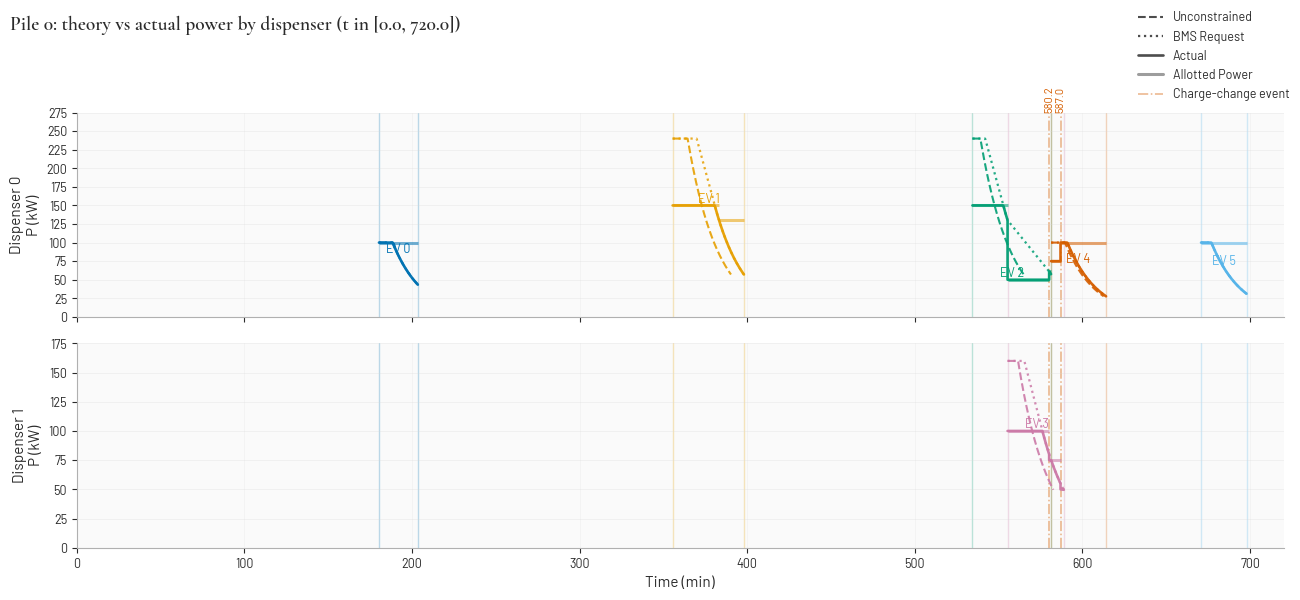

In [23]:
fig = plot_pile_connector_power(
    env,
    0,
    t_start=None,
    t_end=None,
    show_theory=True,
    show_sim_bms=True,
    show_actual=True,
    show_legend=True,
    label_theory="Unconstrained",
    label_sim_bms="BMS Request",
    label_actual="Actual",
    label_charge_steps="Allotted Power",
    show_charge_change_lines=True,
    show_charge_change_vlines=True,
    show_trace_labels=False,
    title=None,
    show_event_lines=True,
    event_line_alpha=0.25,
    show_ev_ids=True,
)
fig


In [28]:
from visualization.pile_power import plot_pile_connector_power
from offline_cl_opt import plot_pile_power_and_modules_v2

PLOT_KW = dict(
    pile_id=0,
    t_start=500,
    t_end=600,
    show_theory=True,
    show_sim_bms=True,
    show_actual=True,
    show_legend=True,
    label_theory="Unconstrained",
    label_sim_bms="BMS Request",
    label_actual="Actual",
    label_charge_steps="Allotted Power",
    show_charge_change_lines=True,
    show_charge_change_vlines=True,
    show_trace_labels=False,
    show_event_lines=True,
    event_line_alpha=0.25,
    show_ev_ids=True,
)

fig_sim = plot_pile_connector_power(env, **PLOT_KW)
fig_opt = plot_pile_power_and_modules_v2(cl_model, **PLOT_KW)


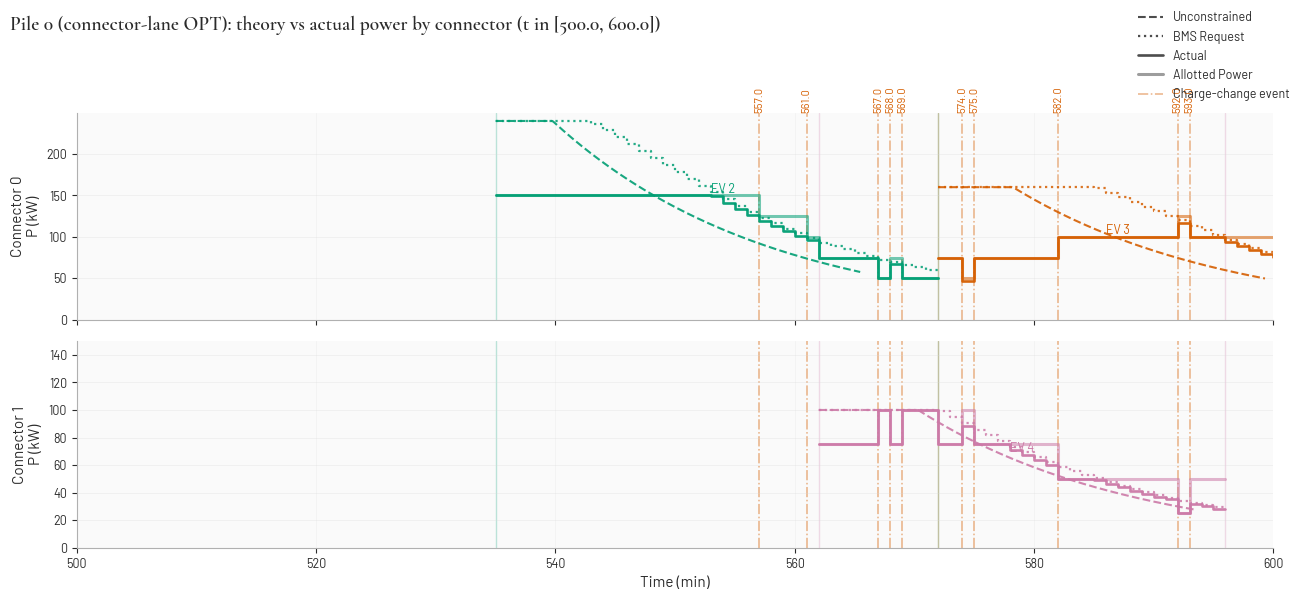

In [29]:
fig_opt

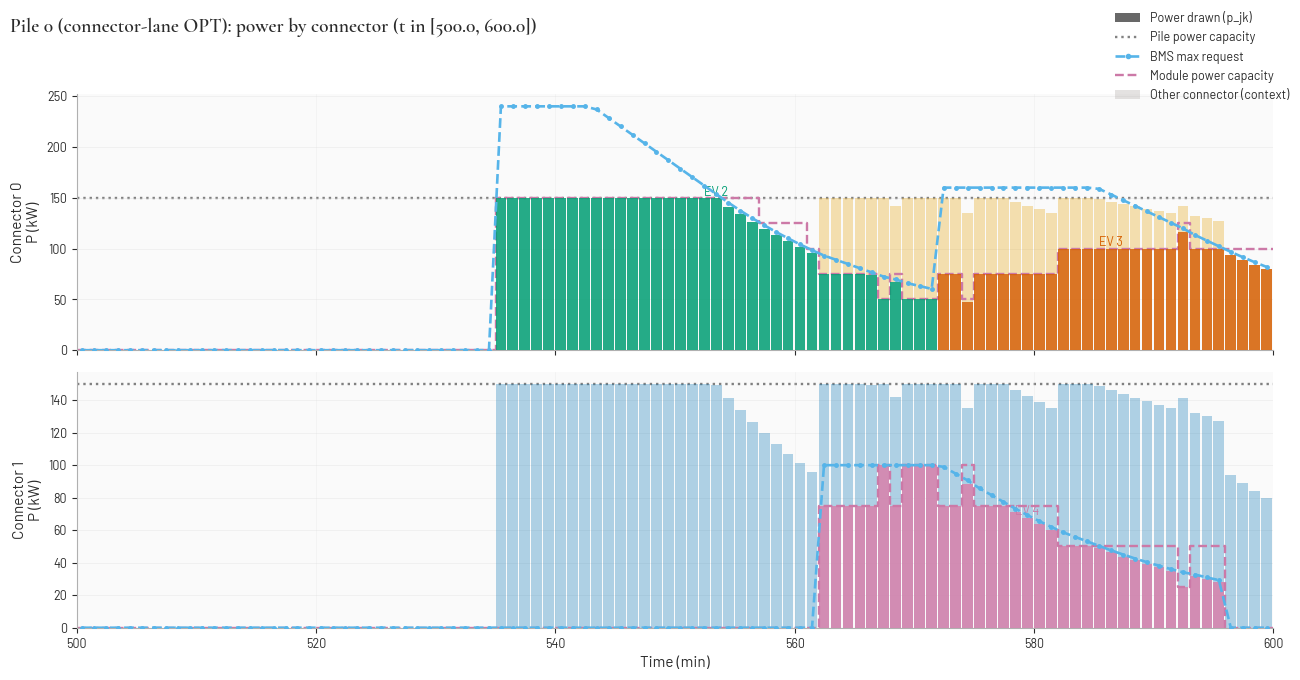

In [31]:
from offline_cl_opt import plot_pile_power_and_modules
import matplotlib.pyplot as plt

fig = plot_pile_power_and_modules(
    cl_model,
    pile_id=0,                    # <- enter a pile id here
    t_start=500,                  # <- enter a time-window subset (None -> actual activity on this pile)
    t_end=600,
    stack_other_connectors=True,     # toggle: stack other connectors' power on top
    other_alpha=0.3,             #         (same pile, low alpha, for context)
    show_bms_request=True,
    show_modules=True,
    bar_width=0.9,
    show_ev_ids=True,
    show_pile_capacity=True
)
fig

Plotting EV 10 (pile 0, connector 1), charts=['P-S', 'T-S', 'P-T'], trace_len=4
Plotting EV 11 (pile 0, connector 0), charts=['P-S', 'T-S', 'P-T'], trace_len=2
Plotting EV 12 (pile 0, connector 0), charts=['P-S', 'T-S', 'P-T'], trace_len=3
Plotting EV 13 (pile 0, connector 0), charts=['P-S', 'T-S', 'P-T'], trace_len=3
Plotting EV 14 (pile 0, connector 0), charts=['P-S', 'T-S', 'P-T'], trace_len=9


[<Figure size 1620x400 with 3 Axes>,
 <Figure size 1620x400 with 3 Axes>,
 <Figure size 1620x400 with 3 Axes>,
 <Figure size 1620x400 with 3 Axes>,
 <Figure size 1620x400 with 3 Axes>]

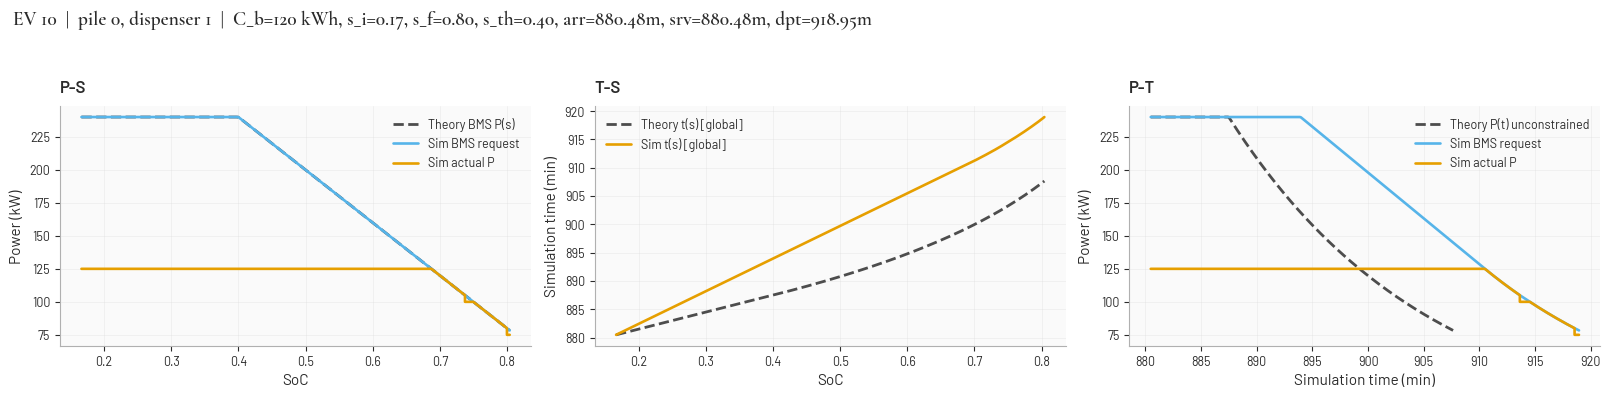

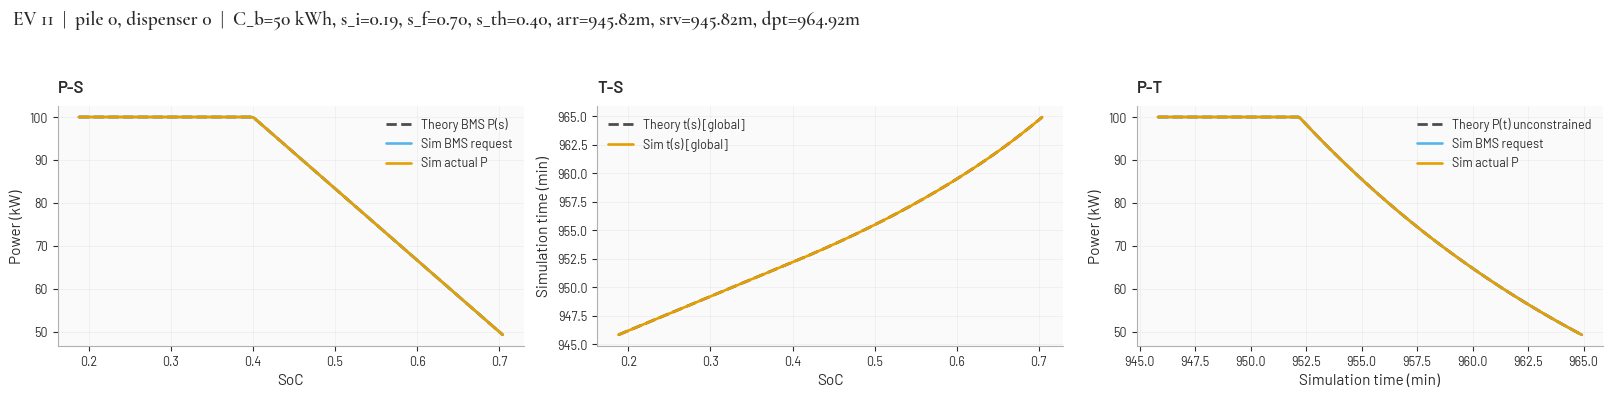

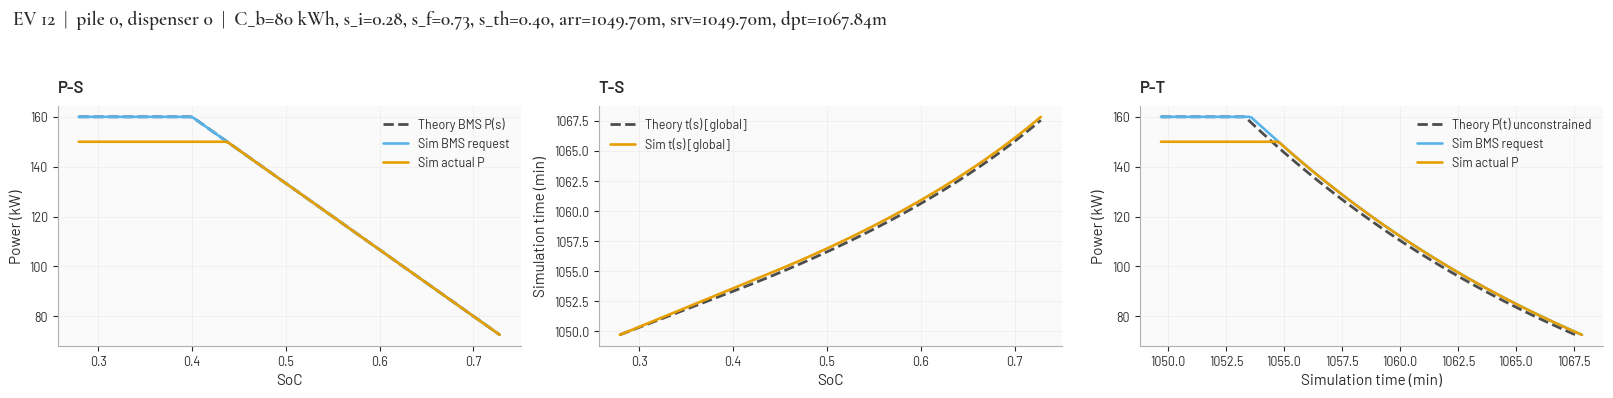

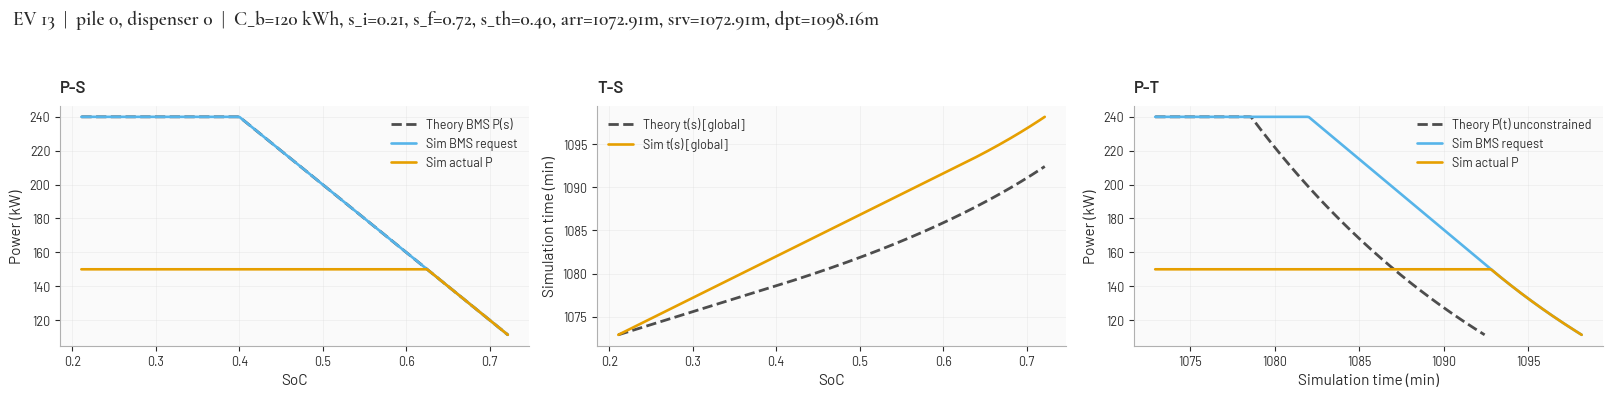

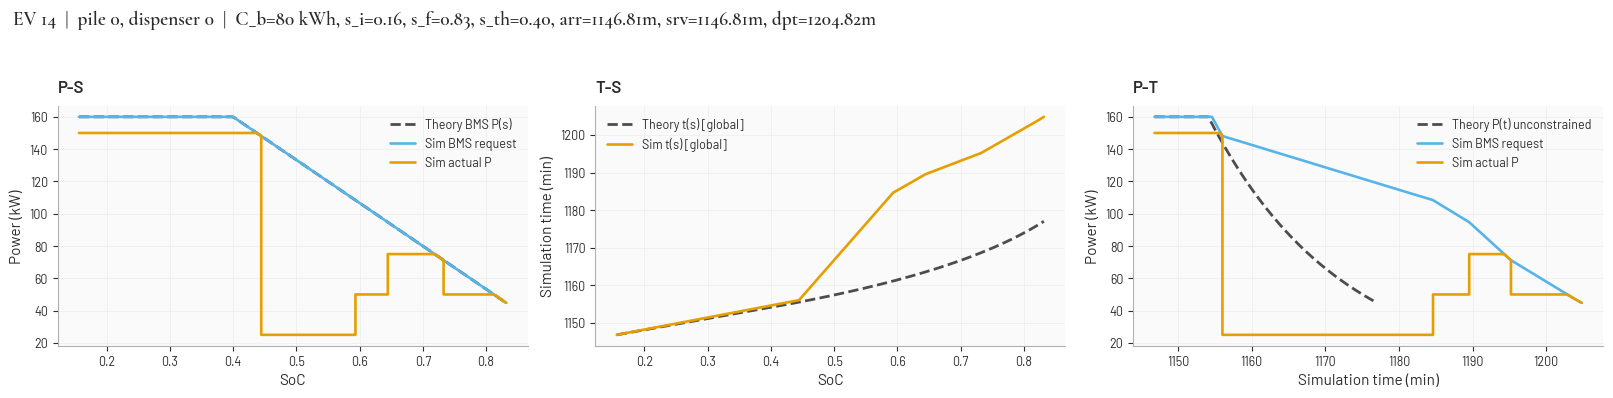

In [17]:
figs = plot_ev_theory_vs_sim(
    env,
    ev_ids=[10 + i for i in range(5)],
    charts=["P-S", "T-S", "P-T"],
    show_theory=True,
    show_sim_bms=True,
    show_sim_actual=True,
    show_recorded_samples=False,
    label_theory=None,
    label_sim_bms=None,
    label_sim_actual=None,
    label_recorded=None,
)
figs
